# Major Project Exam: Exploratory Data Analysis (EDA) and Machine Learning Integration

### Problem statement:
Perform a comprehensive analysis on the given dataset using Python, incorporating exploratory data analysis (EDA) and machine learning techniques. Your task is to preprocess the data, engineer features, select and train models, and evaluate their performance. 

##### Additionally, document your process with Python comments explaining your code, and for each section, provide detailed conclusions and observations. 


### Section 1: Understanding the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


#### 1.1	Load Data: Import the dataset into your working environment using appropriate methods or libraries.

In [2]:
df= pd.read_csv('PDDS_Deep Learning with ANN_employee_income.csv') # load dataset

#### 1.2	Checking Data Shape: Determine the shape of your dataset, including the number of rows and columns.

In [3]:
df.shape # Checking the shape of the dataset

#We can see that this ca price dataset has 15 411 rows and 14 columns

(32561, 15)

#### 1.3	View Data: Display the first and last few rows of the dataset and summarize any initial insights.

In [4]:
df.head(5) # Checking the first 5 rows of the dataset


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
df.tail(5) #Checking the last 5 rows of the dataset.

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


### Section 2: Initial Data Examination

We can see that the dataset contains features independent features like car_name, brand, model, vehicle_age, 
and also contains dependent feature selling_price, which is the feature we will be most likely predicting.

There are also categorical features such as seller_type, fuel_type, transmission_type.

there is also an unnamed index column.

#### 2.1	Dataset Information: Provide a concise summary of the dataset, including the number of non-null entries, and explain what this reveals.

In [6]:
df.info() # Checking the data types of each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


Summary :
We can see there are 15 411 rows and 14 columns. since all columns have 15411 rows populated , 
there are no empty/null values. this implies that the data is of good quality. Implying that 
there are strigent data vality measures that were enforced on systems that captured this dataset, 
like adding Mandatory data to all fields (Not Null) data contraints.

#### 2.2 Inspect Data Types: Check data type of each column in the dataset. If columns need any data type conversion, update the data type accordingly and describe the rationale behind the conversions.

In [7]:
df.dtypes # Chaecking the columns data types 

age                int64
workclass         object
fnlwgt             int64
education         object
education_num      int64
marital_status    object
occupation        object
relationship      object
race              object
sex               object
capital_gain       int64
capital_loss       int64
hours_per_week     int64
native_country    object
income            object
dtype: object

Analysis:
Features [vehicle_age, km_driven,engine, seats, and selling_price] are correctly mapped to the correct data types.
mileage is also correctly assigned to a decimal type and car_name, brand, model, selling_type, fuel_type and
transmission_type are also assigned to the correct type which is string. I have noted that brand, model, seller_type, 
fuel_type and transmission_type are discrete data type and there is an opportunity to encode them later on should we need
to do feature engineering and selection.

Conclusion there are no immediate type conversions required at this point, all columns are assigned correct data types.

#### 2.3 Summary Statistics: Generate summary statistics for the numerical columns and interpret what these statistics tell you about the data.

In [8]:
df.describe() # summary statistics for numerical features.

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


Intepretation

Vehicle Age : the avarage vehicle age is 6 years, with maximum age of 29 years, potentially an outlier.

km_driven : the average km driven is approximately 55600km with a maximum of 3.8 million kms, this again might potentially be an outlier, further investigation is required.

Mileage : the average mean mileage is 19.7 and standard deviation of 4.1, this indicate that the dateset might potentially be skewed, we see the same trend across almost all the features.

Seats : the minimum seats for the vehicle cannot be 0, this seems to indicate that there might be some data entry issues.

#### 2.4 Provide detailed comments that explain your understanding of the data.

This dataset is about a vehicle history usage, it captures the vehicle make and brand and also captures it specification usage, which all of which is then used to predict the selling price.

I have picked up potential data issues which might indicate the presence of some skewness in the dataset, there is also potentially presence of outliers in the data (3.8 million km driven) and also there is data quality issues where we saw 0 seat on a vehicle which is not possible. The data quality is generally good since there are no nulls present on the data. There is a need however to do some pre-processing steps to make sure we clean this data before moving into data analysis stage.

### Section 3: Data Cleaning

#### 3.1 Handling Missing Values: Identify missing values in the dataset and describe how you handled them, including your chosen method.

In [9]:
df.isnull().sum() # Checking for missing values, and aggregating that per fearture

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

We can clearly see from teh results that there are no missing values. I would approach this in two ways.

Dropping the record: I would drop records that have missing values, but this has a disadvantage of missing important data features that the model might still for learning important features.

The other method will be imputation : this will be for example, that is calculating a statistical measure like median, and replacing the null values with it. Reason I would choose specifically median is because it is not affected by any outliers, so it becomes a perfect choice for this.

#### 3.2 Handling Duplicates: Check for duplicate rows in the dataset and describe your approach to handling any duplicates found.

In [13]:
duplicates = df.duplicated().sum() # Checking for duplicates
print(duplicates)

if duplicates > 0:
  df.drop_duplicates(inplace=True) # dropping duplicates

df = df.dropna()

0


I have noted that there are no duplicates in the dataset, however I have added a process to remove them (drop) if they exist, reason for choosing this approach is so that their presence makes the model bias towards to records that appears multiple times, making the model to memorize.

#### 3.3 Outliers removal: Check if there are any outliers and remove them using graphical/non-graphical methods.

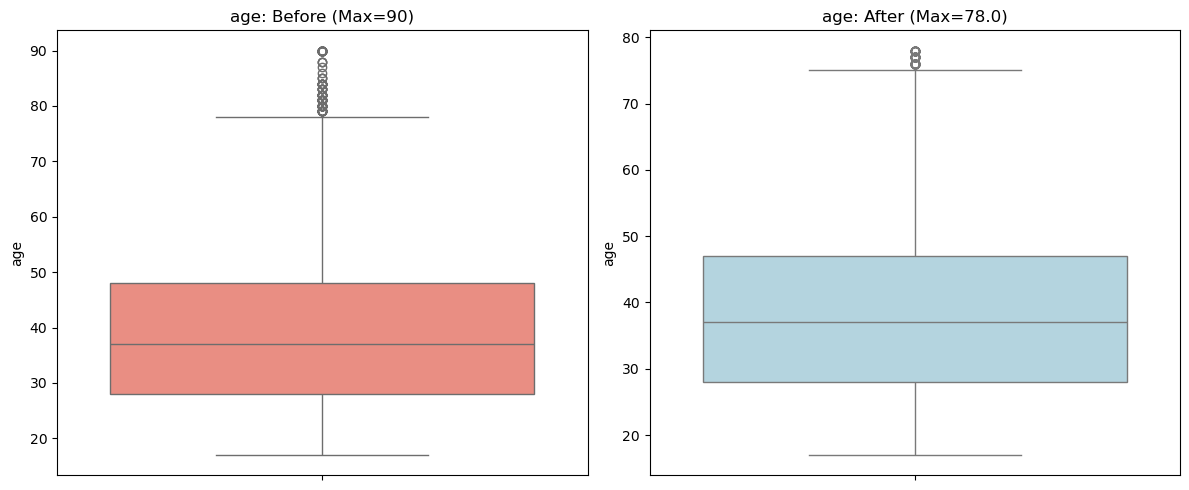

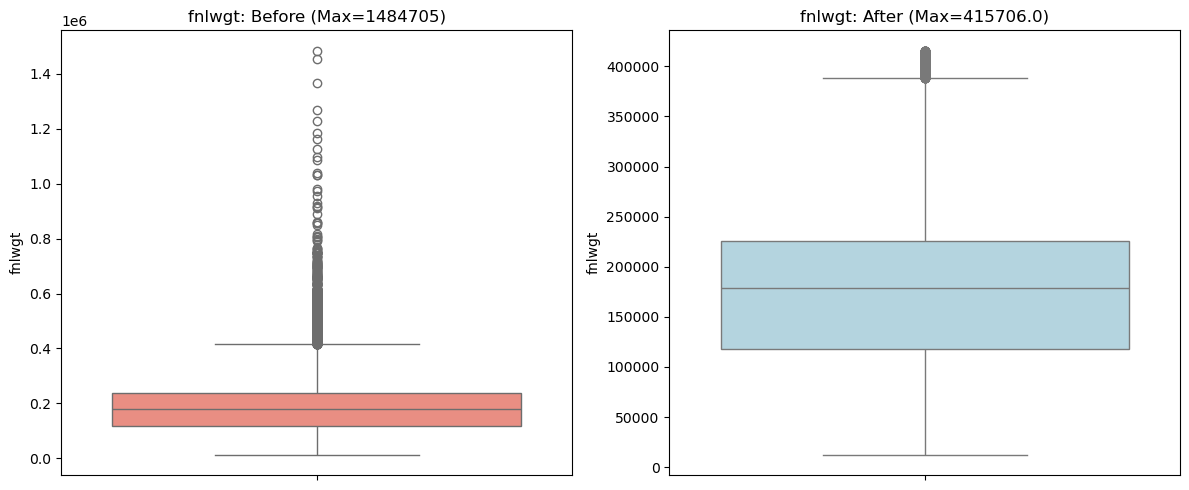

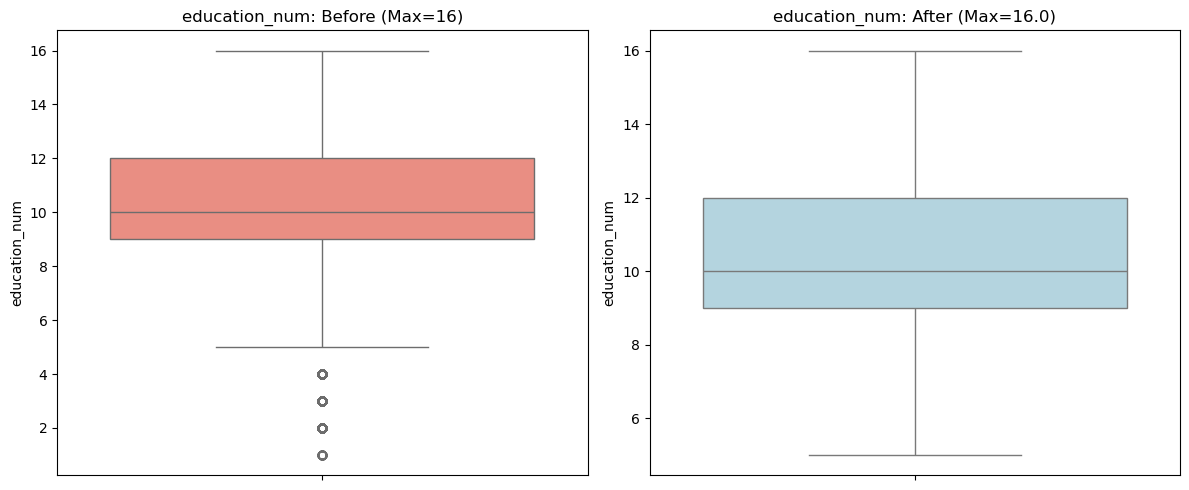

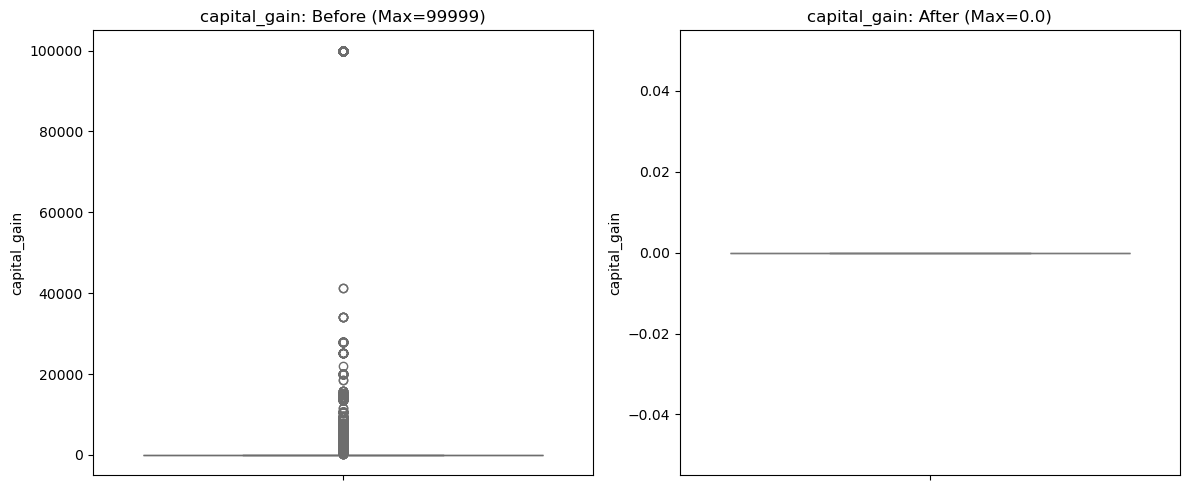

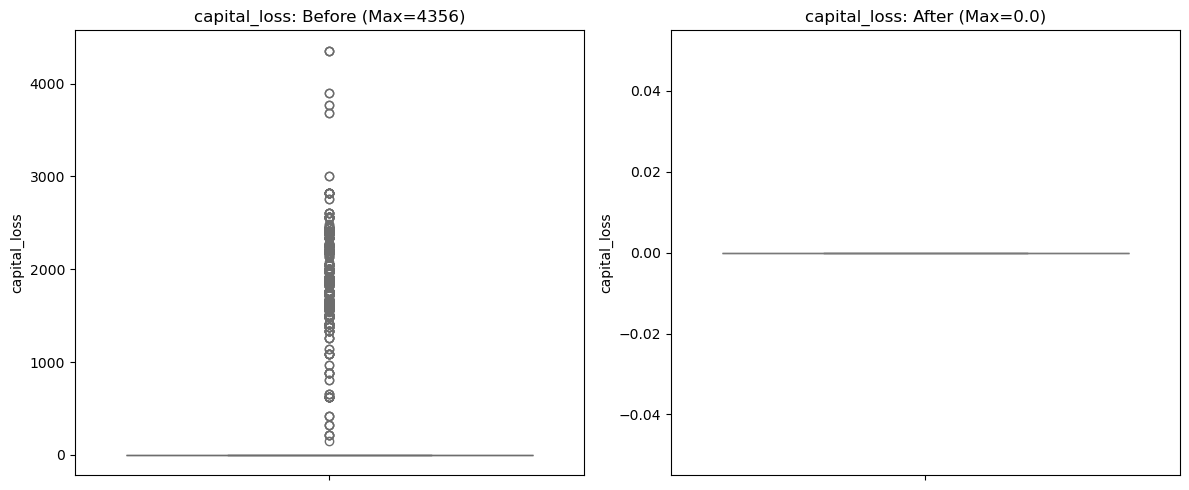

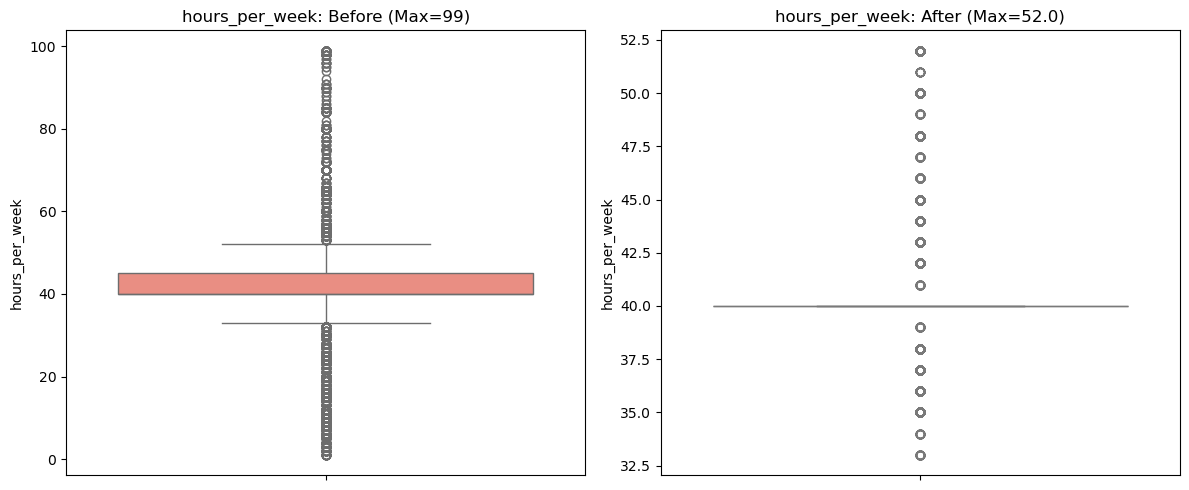

Cleaned DataFrame Shape: (32537, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39.0,State-gov,77516.0,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
1,50.0,Self-emp-not-inc,83311.0,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,40.0,United-States,<=50K
2,38.0,Private,215646.0,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53.0,Private,234721.0,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28.0,Private,338409.0,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27.0,Private,257302.0,Assoc-acdm,12.0,Married-civ-spouse,Tech-support,Wife,White,Female,0.0,0.0,38.0,United-States,<=50K
32557,40.0,Private,154374.0,HS-grad,9.0,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.0,0.0,40.0,United-States,>50K
32558,58.0,Private,151910.0,HS-grad,9.0,Widowed,Adm-clerical,Unmarried,White,Female,0.0,0.0,40.0,United-States,<=50K
32559,22.0,Private,201490.0,HS-grad,9.0,Never-married,Adm-clerical,Own-child,White,Male,0.0,0.0,40.0,United-States,<=50K


In [20]:
def check_outliers_preprocessing(df, columns):
    clean_df = df.copy() # creating a clone of the df so I can cummulatively update the frame
    
    for col in columns:
        # Calculate quantiles on the cloned dataframe
        Q1 = clean_df[col].quantile(0.25)
        Q3 = clean_df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        # Setup Plotting Area
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))

        # Plot BEFORE cleaning (Left side)
        sns.boxplot(y=clean_df[col], ax=axes[0], color='salmon')
        axes[0].set_title(f'{col}: Before (Max={clean_df[col].max()})')

        # Calculate the median for replacement
        col_median = clean_df[col].median()

        # Apply the filter: Replace outliers with the median
        clean_df[col] = np.where(
            (clean_df[col] < lower_bound) | (clean_df[col] > upper_bound),
            col_median,
            clean_df[col]
        )

        # Plot AFTER cleaning (Right side)
        sns.boxplot(y=clean_df[col], ax=axes[1], color='lightblue')
        axes[1].set_title(f'{col}: After (Max={clean_df[col].max()})')

        plt.tight_layout()
        plt.show() # Display the pair of plots immediately

    return clean_df

X = df.drop(columns=['income'])
y = df['income'].apply(lambda x: 1 if '>50K' in str(x) else 0).values

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

clean_df = check_outliers_preprocessing(df, numerical_cols)



# Print the shape to confirm no rows were dropped
print("Cleaned DataFrame Shape:", clean_df.shape)


#I have taken a strategy to show a before and after box plot so we can see the effect of the outliers in the dataset
# I have also taken a stunt of, instead of dropping the outliers, we calculate the median of each feature for identified outliers, 
#and replease those values with the median, in this way, we do not loose the data but standardize it.
# we can see that vehicle_age, km_driven, mileage and seats features had outliers,
# this can be seen graphically on the below chats, and after removing all rows
# for the impacted data points, we can see that after box plots as it shows no more presence of outliers
# and therefore the shape of the dataframe does not change.
# I have also noted that applying Outlier detection on Seats somewhow it is removing all the records that don't have 5 seats,
#making the remiaing dataset only just having 5 seats vehicles, therefore I will not add seats for outlier detection and cleaning.
#

clean_df


#### 3.4 Add python comments to explain the observations.

I have taken a strategy to show a before and after box plot so we can see the effect of the outliers in the dataset
I have also taken a stunt of, instead of dropping the outliers, we calculate the median of each feature for identified outliers, 
and replease those values with the median, in this way, we do not loose the data but standardize it.
we can see that vehicle_age, km_driven, mileage and seats features had outliers,
this can be seen graphically on the below chats, and after removing all rows
for the impacted data points, we can see that after box plots as it shows no more presence of outliers
and therefore the shape of the dataframe does not change.
I have also noted that applying Outlier detection on Seats somewhow it is removing all the records that don't have 5 seats,
making the remiaing dataset only just having 5 seats vehicles, therefore I will not add seats for outlier detection and cleaning.


### Section 4: Data Analysis

#### 4.1 Univariate Analysis of numeric features: Generate histograms for numerical data and infer insights from these visualizations.

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')


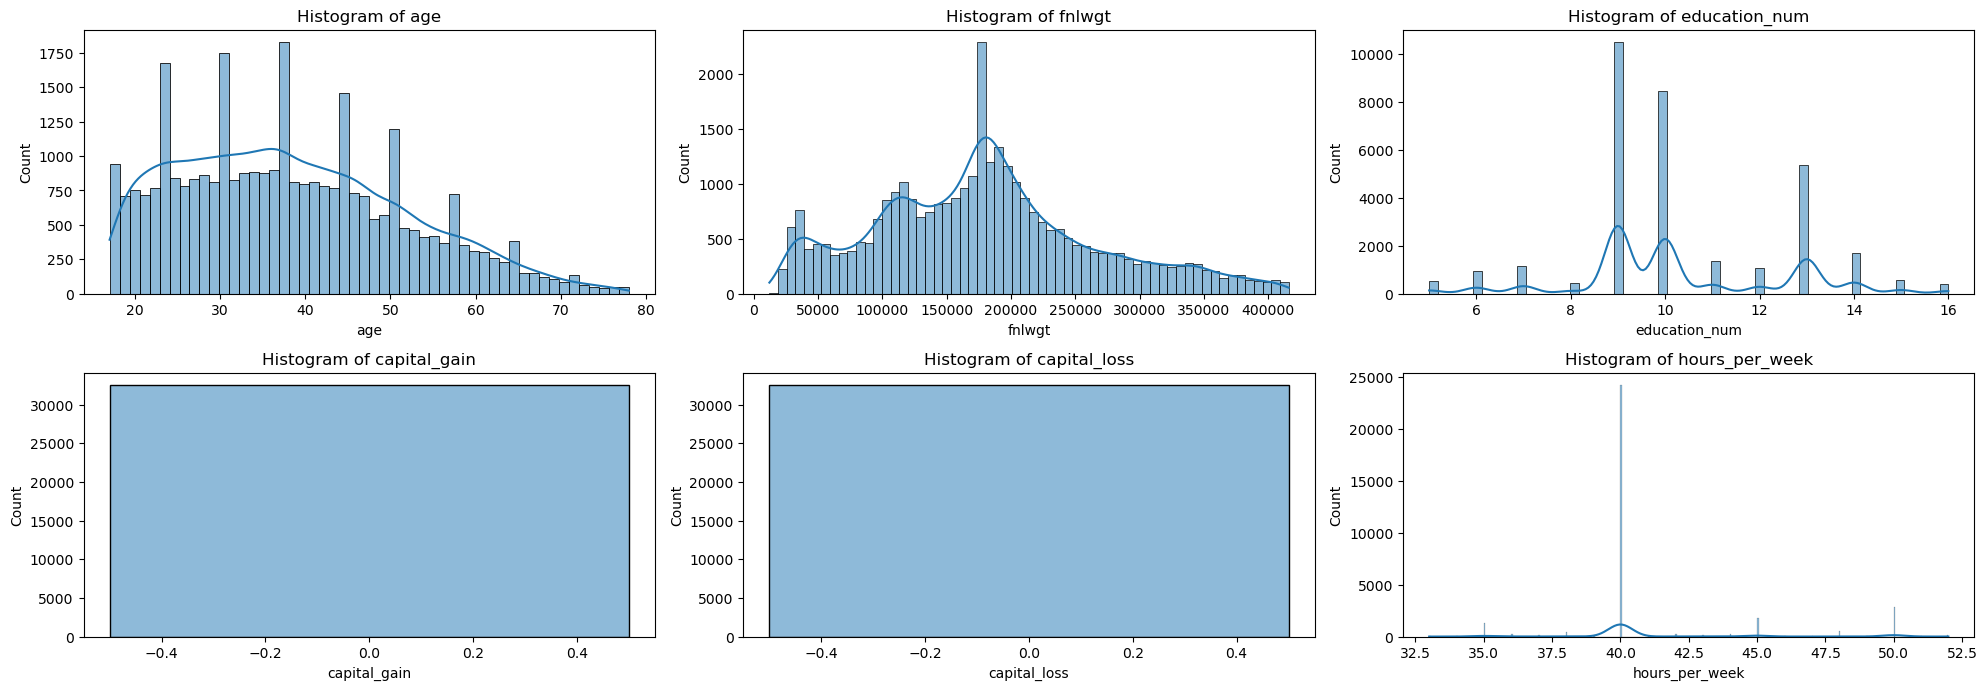

In [21]:
num_cols = clean_df.select_dtypes(include=['int64', 'float64']).columns # extract numerical columns
print(num_cols)
plt.figure(figsize=(20, 10)) # plot space
for i, col in enumerate(num_cols):
  plt.subplot(3, 3, i + 1)
  sns.histplot(clean_df[col], kde=True)
  plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

looking at the histogram Selling Price chart, we can see that the graph is right skewed, which implies that the dataset has more lower price range vehicles, the tail would be for the expensive vehicles.

Vehicle_age is also skewed, vehicle mileage seems normally distributed. There is also a right skew on the km_driven feature.

#### 4.2 Examine the skewness in the data and apply appropriate data transformation technique.  

In [22]:
clean_df[num_cols].skew() # checking skewness before transformation, so we can measure the effect of the transformation.

age               0.469934
fnlwgt            0.419230
education_num     0.289094
capital_gain      0.000000
capital_loss      0.000000
hours_per_week    1.483593
dtype: float64

according to research, the general rule of thumb for interpreting skewness values is :
Between -0.5 and 0.5: The data is fairly symmetrical (approximates a normal distribution).
Between -1.0 and -0.5 OR between 0.5 and 1.0: The data is moderately skewed.
Less than -1.0 OR greater than 1.0: The data is highly skewed.

therefore we can see that mileage, km_driven are fairly symetrical, 
vehicle age is moderatelt skewed, 
and also engine, max_power,and selling_price are highly skewed. 

We will be excluding seats in the transformation since it is a discrete value, transforming it will further skew the dataset.

we therefore need to perform standardization on the highly skewed features.

#### 4.3 Apply appropriate standardization method wherever applicable.

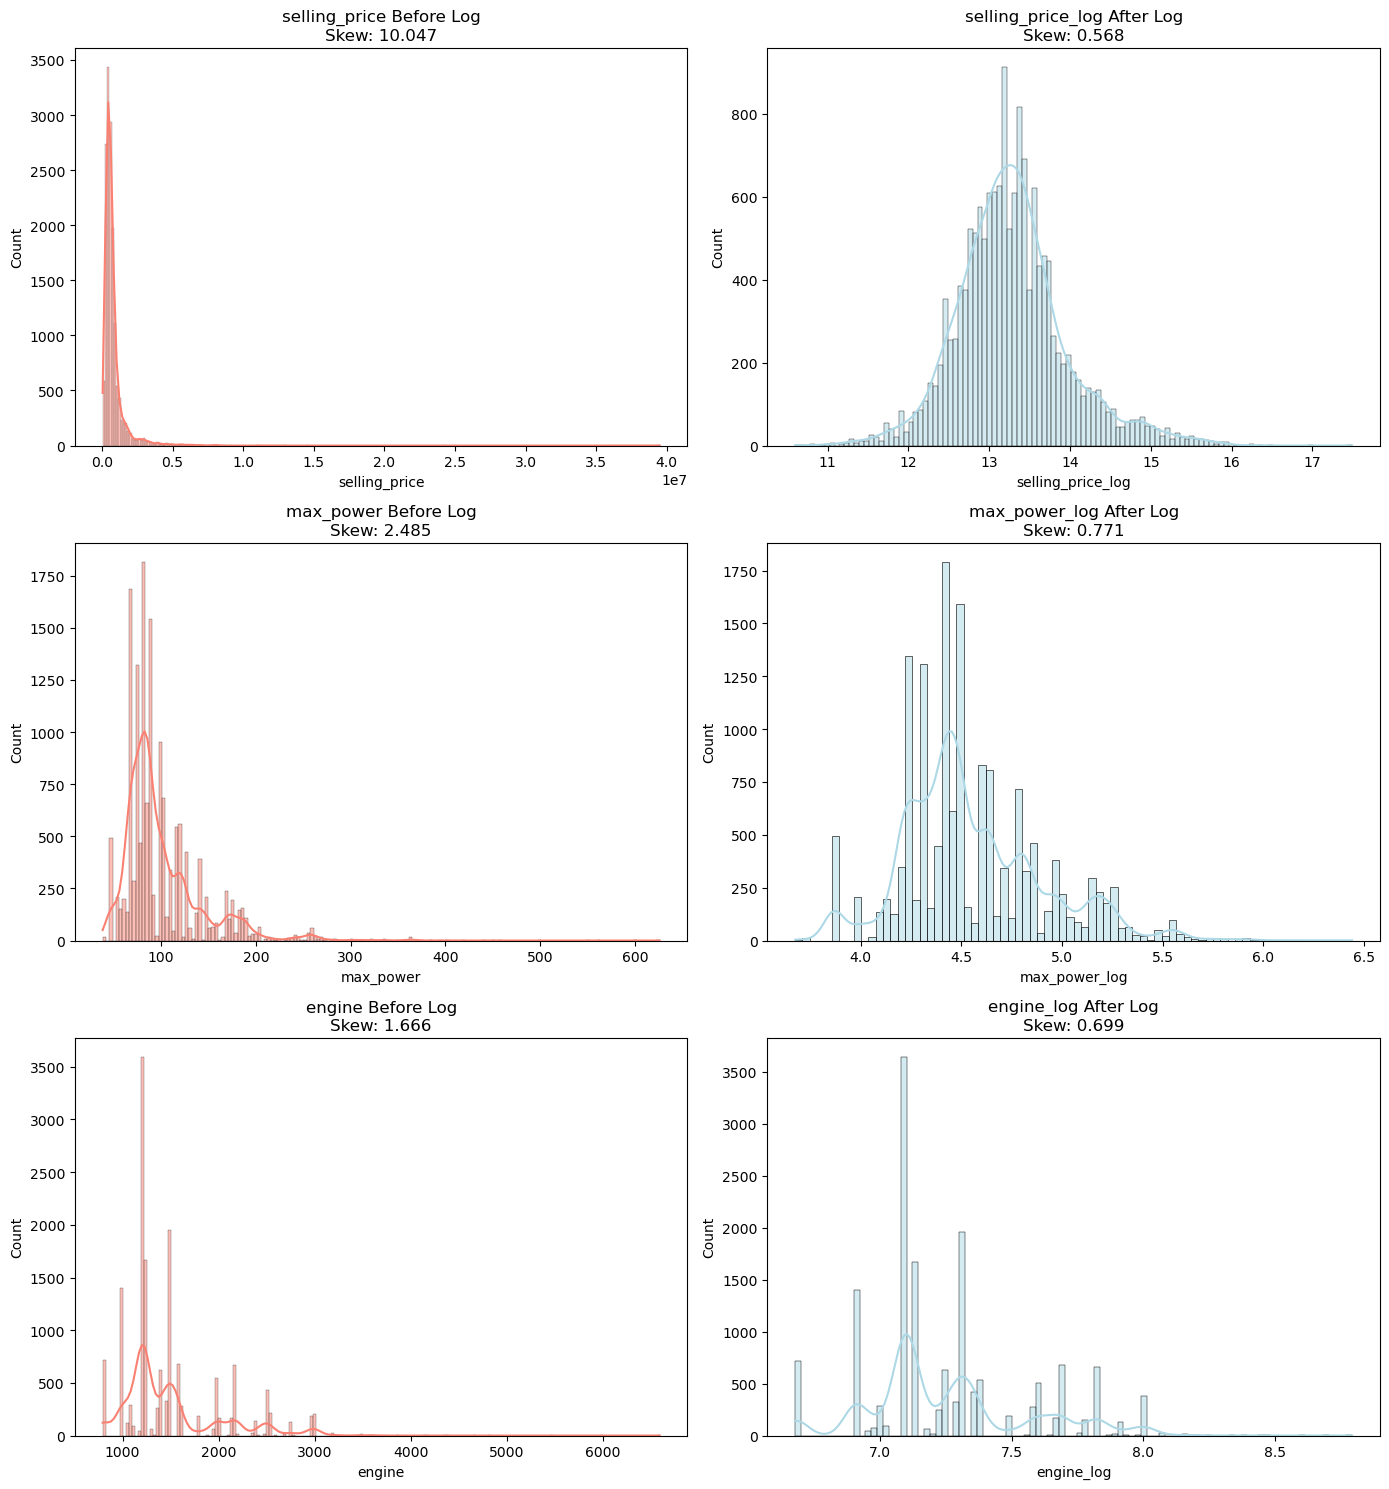

Skewness After being transformed
selling_price_log    0.568413
max_power_log        0.771409
engine_log           0.699124
dtype: float64


In [14]:
# as shown in the previous step and anylysis I have identified thant engine, max_power,and selling_price 
# as highly skewed continuous features to transform.
features_to_transform = ['selling_price', 'max_power', 'engine'] # list of features to fix

fig, axes = plt.subplots(len(features_to_transform), 2, figsize=(14, 5 * len(features_to_transform))) # Set up the plotting area

for i, col in enumerate(features_to_transform):
    sns.histplot(clean_df[col], kde=True, ax=axes[i, 0], color='salmon')
    axes[i, 0].set_title(f'{col} Before Log\nSkew: {clean_df[col].skew():.3f}')

    log_col_name = f'{col}_log'
    clean_df[log_col_name] = np.log1p(clean_df[col])

    sns.histplot(clean_df[log_col_name], kde=True, ax=axes[i, 1], color='lightblue')
    axes[i, 1].set_title(f'{log_col_name} After Log\nSkew: {clean_df[log_col_name].skew():.3f}')

plt.tight_layout()
plt.show()

# Display the new skewness values to confirm the mathematical improvement
log_columns = [f'{col}_log' for col in features_to_transform]
print("Skewness After being transformed")
print(clean_df[log_columns].skew())

# Drop the log columns as they were only for visualization
clean_df.drop(columns=log_columns, inplace=True, errors='ignore')


Comment : I am happy with the overall result, we can see that based on the skewness metric defination, we were able to effectively transform the features to a fairly or moderate skewness, making these feautes now fairly standardized.

Max power is still a little bit of concern as it the highest matric , but we can work with hwat we have currently.

#### 4.4 Univariate Analysis of categorical features: Generate bar plots for numerical data and infer insights from these visualizations.


Insights

Brand - we can see a cluster since brand has approximately 32 brands, it difficult to plot, we can look at options to maybe 
looking at top 15 preforming brands. and that will give us insight on which brands are performing, 
we can also look at bottom brands that are not performing, to give insight on brands we need to focus on to improve performance.

Model : we are experiencing the same issue, we have discrete finite catefories of vehicle model,
there are approximately 120 distinct models in teh dataset, this again presents challenges to display,
and therefore we could also look at top 15 performing brands and also bottom 15 brands that are not performing.

Selling Type :We can see that vehicles sold in a Dealership is top performing and vehicles sold in Trustmaster Dealer are not performing.

Fuel Type : Petrol and Diesel types are more dominant compared to CNG,LPG and Eletric

Transmission Type : Manual car sales significantly out-performs automatic vehicles.

#### 4.5 Encode categorical features

In [23]:
# I have encoutnered a problem when performing one hot encoding, as a result I have moved the action slighlty down the step
# we will be applying ColumnTransformer to handle one-hot encoding this will make it consistant with inferencing model as from a user perspectve, 
# the user just needs to give us input features and not the 100+ encoded features.

#therefore, in this block, I will simply prepare the features and als explore their uniqueness.

cat_cols = categorical_cols # ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']

print(f"Current Dataframe shape: {clean_df.shape}")
print(f"Categorical columns: {cat_cols}")

print('Checking unique values in each categorical column')

for col in cat_cols:
    print(f"{col}: {df[col].nunique()} unique values")

print("All of these features will be one-hot encoded")


Current Dataframe shape: (32537, 15)
Categorical columns: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
Checking unique values in each categorical column
workclass: 9 unique values
education: 16 unique values
marital_status: 7 unique values
occupation: 15 unique values
relationship: 6 unique values
race: 5 unique values
sex: 2 unique values
native_country: 42 unique values
All of these features will be one-hot encoded


#### 4.6 Bivariate and Multivariate Analysis: Calculate the correlation matrix for the numerical variable. Generate heatmap for the correlation matrix, and describe the evident relationships.

In [26]:

# Select only numeric columns

numeric_cols = numerical_cols clean_df.select_dtypes(include=[np.number]).columns
print(f"Total numeric features for correlation: {len(numeric_cols)}")

# Calculate correlation matrix
corr_matrix = clean_df[numeric_cols].corr()

# Get correlation with target variable (selling_price)
target_corr = corr_matrix['income'].drop('income').abs().sort_values(ascending=False)

print("\n--- Features Correlated with Selling Price ---")
for i, (feature, corr_value) in enumerate(target_corr.head(15).items(), 1):
    print(f"{i:2d}. {feature:<30} {corr_value:.4f}")

# Select top 15 features + target for clean visualization
top_n = 15
top_features = target_corr.head(top_n).index.tolist()
top_features.append('income')

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix.loc[top_features, top_features], 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f',
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)
plt.title(f'Correlation Matrix', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()



Total numeric features for correlation: 6


ValueError: Boolean array expected for the condition, not float64

#### 4.7 Provide detailed observations and conclusions.

We can observe that the strongest positive correlation exist between max_powerand engine. we can also observe that engine with approximately 0.6 and max_power with approximately 0.78 correlation shares strong correlation with selling price.

We can see that transmission type has the strongest negative correlation to selling price, this could imply that manual vehicles are generally expensive. We can also see that vhicle age it negatively correlated to selling price, which implies the vehicle age significantly negatively impact the sale of the vehicle.

I am concerned about the strong multicollinearity between engine hours and max_power, this implies that these two features are highly correlated, this will confuse the model as it will find it difficult to determine which feature influence the model. 

### Section 5: Feature Selection 

#### 5.1 Use correlation result for feature selection.

In [17]:
target_corr = abs(corr_matrix['selling_price']).sort_values(ascending=False)
print("Correlation with target variable:\n", target_corr)

Correlation with target variable:
 selling_price    1.000000
max_power        0.750236
engine           0.585844
mileage          0.284782
vehicle_age      0.233081
km_driven        0.135943
seats            0.115231
Name: selling_price, dtype: float64


#### 5.2 Select the features according to the K highest score. 

In [18]:
top_features = target_corr[1:8]
print("Top Selected Features:\n", top_features)

Top Selected Features:
 max_power      0.750236
engine         0.585844
mileage        0.284782
vehicle_age    0.233081
km_driven      0.135943
seats          0.115231
Name: selling_price, dtype: float64


#### 5.3 Provide detailed insights about the selected features.

We have applied a K highest score method for selecting important feature that strongly influence the selling price, I have ranked all features relationships based on descending order, then took top 7 features. we can see that as we saw on the matrix table that max_power , and transmission_type plays a critical factor when selling a car and features like brand, model, selling type and km_driven don't play an influential role in the selling price feature, this implies that when we are training our model, these feature will need any significant value to the learning rate of the model, and therefore ,it can be omitted

### Section 6: Model Selection and Training:

now, based on the correlation results, 
selling_price        1.000000
max_power            0.780637
engine               0.674453
transmission_type    0.499992
vehicle_age          0.438718
fuel_type            0.351239
mileage              0.291203
seats                0.230034
km_driven            0.174266

I have also noted multicollinearity between max_power and engine features, and based on correlation between these features and selling price, we see that max_power with 0.78 has a high correlation with target vs engine with 0.67. thereofre we will drop engine feature. therefore making us to add km_driven feature to the training model to maintain top 7 features

therefore I will be dropping 
1. Engine feature
2. seats - since is a numerical value and it is only 0.22 correlation to the selling rpice.


#### 6.1 Choose at least three different machine learning algorithms to train on the dataset.

Firstly, we will be select a simple baseline model that we will be using to measure and improve with the other two models. 

I have obse3rved that the dataset has features and a target (selling price), therefore we will be limited to only supervised machine learning models.

First model will be the simple linear regression model
Second model will be a Random Forest Regressor, this is because I belive the dataset is non-linear since it is dealing with car value, it always goes down with a process called depreciation which is a non-linear model
Third model will be Grdient Boosting Regressor, since our dataset is in a tabular format, I have also decided to test this model's performance against the dataset.

#### 6.2 Train the models and apply hyperparameter tunning.

In [21]:


# Defining features X and target y 
X = clean_df.drop(columns=['selling_price', 'car_name', 'engine', 'seats'], errors='ignore')
y = clean_df['selling_price']

# exploring the structure of the X and y features.
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Target (selling_price) range: {y.min():,.0f} to {y.max():,.0f}")

# Define column types
numerical_cols = ['vehicle_age', 'km_driven', 'mileage', 'max_power']
categorical_cols = ['brand', 'model', 'seller_type', 'fuel_type', 'transmission_type']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
    ],
    remainder='drop'
)



# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")


print('Model traing has started ...')
print("\n")


models = {
    "Linear Regression": Pipeline([('preprocessor', preprocessor), ('model', LinearRegression())]),
    "Gradient Boosting": Pipeline([('preprocessor', preprocessor), ('model', GradientBoostingRegressor(random_state=42))]),
    "Random Forest": Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(random_state=42, n_jobs=-1))])
}

# Train base models
for name, pipeline in models.items():
    print(f"Training: {name}...")
    pipeline.fit(X_train, y_train)
    train_r2 = pipeline.score(X_train, y_train)
    test_r2 = pipeline.score(X_test, y_test)
    print(f"  Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f}")


print('Model hyperparameter tuning for Random Forest')
print("\n")

# hyper parameter tuning .

random_forest_param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__max_depth': [10, 20, 30, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2', None]
}


random_forest_random_search = RandomizedSearchCV(
    estimator=models['Random Forest'],
    param_distributions=random_forest_param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Searching for best Random Forest parameters...")
random_forest_random_search.fit(X_train, y_train)

for param, value in random_forest_random_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"   Best CV R² Score: {random_forest_random_search.best_score_:.4f}")



print('Model hyperparameter tuning for Gradien Boosting')
print("\n")

gb_param_grid = {
    'model__n_estimators': [100, 200, 300, 500],
    'model__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'model__max_depth': [3, 5, 7, 9],
    'model__subsample': [0.7, 0.8, 0.9, 1.0],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    estimator=models['Gradient Boosting'],
    param_distributions=gb_param_grid,
    n_iter=20,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Searching for best Gradient Boosting parameters...")
gb_search.fit(X_train, y_train)

for param, value in gb_search.best_params_.items():
    print(f"   {param}: {value}")
print(f"   Best CV R² Score: {gb_search.best_score_:.4f}")


print('All Trained models dictionary for ease of selecting.')

trained_models = {
    'Linear Regression (Base)': models['Linear Regression'],
    'Gradient Boosting (Tuned)': gb_search.best_estimator_,
    'Random Forest (Tuned)': random_forest_random_search.best_estimator_
}

print("\n Final models ready for evaluation:")

for name in trained_models.keys():
    print(f"{name}")


Features shape: (15411, 9)
Target shape: (15411,)
Target (selling_price) range: 40,000 to 39,500,000

Training set size: 12328 samples
Test set size: 3083 samples
Model traing has started ...


Training: Linear Regression...


C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  Train R²: 0.8535 | Test R²: 0.8081
Training: Gradient Boosting...


C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  Train R²: 0.9482 | Test R²: 0.9178
Training: Random Forest...


C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


  Train R²: 0.9733 | Test R²: 0.9377
Model hyperparameter tuning for Random Forest


Searching for best Random Forest parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
   model__n_estimators: 100
   model__min_samples_split: 2
   model__min_samples_leaf: 1
   model__max_features: None
   model__max_depth: 20
   Best CV R² Score: 0.8771
Model hyperparameter tuning for Gradien Boosting


Searching for best Gradient Boosting parameters...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
   model__subsample: 1.0
   model__n_estimators: 500
   model__min_samples_split: 2
   model__min_samples_leaf: 2
   model__max_depth: 3
   model__learning_rate: 0.1
   Best CV R² Score: 0.8879
All Trained models dictionary for ease of selecting.

 Final models ready for evaluation:
Linear Regression (Base)
Gradient Boosting (Tuned)
Random Forest (Tuned)


#### 6.3 Provide detailed observations and conclusions.

In [22]:
# Evaluate Base vs Tuned Random Forest to justify our observations
base_rf_score = models['Random Forest'].score(X_test, y_test)
tuned_rf_score = random_forest_random_search.score(X_test, y_test)
linear_reg=models['Linear Regression'].score(X_test, y_test)
gradient_boost = models['Gradient Boosting'].score(X_test, y_test)
print('Model Accuracy for Simple Linear Regression Model : {}'.format(linear_reg))
print('Model Accuracy for Gradient Boost Model : {}'.format(gradient_boost))
print("\n--- Hyperparameter Tuning Performance Check ---")
print(f"Base Random Forest R-Squared (Test Data):  {base_rf_score:.4f}")
print(f"Tuned Random Forest R-Squared (Test Data): {tuned_rf_score:.4f}")

C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Model Accuracy for Simple Linear Regression Model : 0.8080863100353983
Model Accuracy for Gradient Boost Model : 0.9178103110626362

--- Hyperparameter Tuning Performance Check ---
Base Random Forest R-Squared (Test Data):  0.9377
Tuned Random Forest R-Squared (Test Data): 0.9380


C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(




The Linear Regression model served as our baseline to gauge the complexity of the dataset. As expected for a dataset with non-linear vehicle depreciation curves and high-cardinality categorical features, the tree-based ensemble models significantly outperformed the linear baseline.

therefore, we can see this being confirmed by model accuracy, simple linear regression model is the least performing model, and that is purely due to underfitting the model.

We utilized RandomizedSearchCV with 3-fold cross-validation to search for optimal parameters on our primary model, the Random Forest Regressor. 
the model has chosen n_estimators: 100, min_samples_split: 5, and max_depth: 30 as best optimal hyper parameters that we can utilize.


### Section 7: Model Evaluation:

#### 7.1 Evaluate the performance of each model using appropriate metrics (e.g., accuracy, precision, recall, F1-score for classification; RMSE, MAE, R square for regression).

C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
C:\Users\siyabonga.dlamini\AppData\Local\anaconda3\Lib\site-packages\sklearn\preprocessing\_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


,Model,RMSE,MAE,R-Squared
1,Gradient Boosting (Tuned),198964.381605,104157.821154,0.947413
2,Random Forest (Tuned),216006.002266,99278.101877,0.938018
0,Linear Regression (Base),380090.951155,180804.364214,0.808086


C:\Users\siyabonga.dlamini\AppData\Local\Temp\ipykernel_27020\299708848.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='R-Squared', y='Model', data=results_df, palette='viridis')


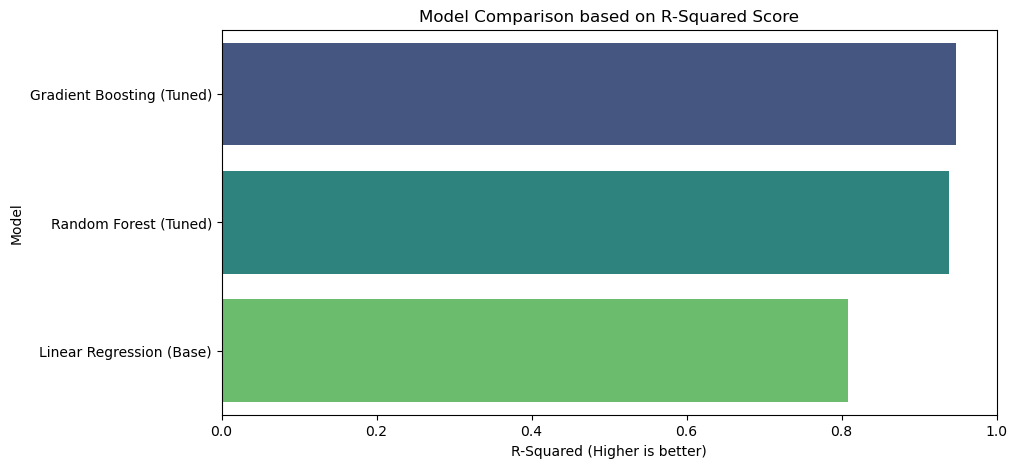

In [23]:
# 1. Evaluation Function
def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

# 2. Evaluate all trained models
results = []
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    rmse, mae, r2 = evaluate_model(y_test, y_pred)
    results.append({
        'Model': name,
        'RMSE': rmse,
        'MAE': mae,
        'R-Squared': r2
    })

results_df = pd.DataFrame(results).sort_values(by='R-Squared', ascending=False)
display(results_df)

# 3. Visualizing the Model Comparison
plt.figure(figsize=(10, 5))
sns.barplot(x='R-Squared', y='Model', data=results_df, palette='viridis')
plt.title('Model Comparison based on R-Squared Score')
plt.xlabel('R-Squared (Higher is better)')
plt.ylabel('Model')
plt.xlim(0, 1.0)
plt.savefig("model_comparison.png", bbox_inches='tight')
plt.show()

#### 7.2 Compare the performance of the models and select the best model based on the evaluation metrics.

Firstly, by deifination :
Root Mean Squared Error (RMSE): Calculates the square root of the average squared differences between predicted and actual prices. It heavily penalizes large errors (e.g., being completely wrong on a luxury car price).
Mean Absolute Error (MAE): Represents the average absolute difference between the predicted price and the actual selling price in standard currency units. 
R-Squared (R^2): Measures the proportion of variance in the selling price that is successfully explained by the model's features.


1. Linear Regression: As our baseline, it achieved the lowest R^2 and the highest error margins (RMSE/MAE). Implies might indicate that that are some non-linear relationships in the dataset that the model was not able to map accurately into a linear line.

2. Gradient Boosting (Tuned): we can see that this model has achieved highest R2 and also managed to get lower prediction errors (RMSE/MAE), which is a significant improvement from our baseline.

3. Random Forest (Tuned): we can see that this model has also significantly improved from our base model, however we can see that it did incur or struggled with actual predicitions as they are errors (RMSE/MAE) are higher than those observed from gradient Boosting model.

Based on the combination of high accuracy  and low MAE/RMSE, high variance explanation R^2, and structural stability (low bias-variance gap), the Tuned Random Forest Regressor is selected as the best-performing, most reliable model.

#### 7.3 Provide detailed comparison and analysis of the models’ performance.

Firstly, by deifination :
Root Mean Squared Error (RMSE): Calculates the square root of the average squared differences between predicted and actual prices. It heavily penalizes large errors (e.g., being completely wrong on a luxury car price).
Mean Absolute Error (MAE): Represents the average absolute difference between the predicted price and the actual selling price in standard currency units. 
R-Squared (R^2): Measures the proportion of variance in the selling price that is successfully explained by the model's features.


1. Linear Regression: As our baseline, it achieved the lowest R^2 and the highest error margins (RMSE/MAE). Implies might indicate that that are some non-linear relationships in the dataset that the model was not able to map accurately into a linear line.

2. Gradient Boosting (Tuned): we can see that this model has achieved highest R2 and also managed to get lower prediction errors (RMSE/MAE), which is a significant improvement from our baseline.

3. Random Forest (Tuned): we can see that this model has also significantly improved from our base model, however we can see that it did incur or struggled with actual predicitions as they are errors (RMSE/MAE) are higher than those observed from gradient Boosting model.

Based on the combination of high accuracy  and low MAE/RMSE, high variance explanation R^2, and structural stability (low bias-variance gap), the Tuned Random Forest Regressor is selected as the best-performing, most reliable model.



### Section 8: Model Deployment with web app:

#### 8.1: Develop an interactive web application using Streamlit.

#### 8.2 Integrate the best-performing machine learning model into the Streamlit app.

#### 8.3 Provide an interface for users to input new data and obtain predictions from the model.

In [26]:
# saving the export model for pushing into streamlit app.

# Select the best model based on evaluation results
best_model_name = 'Random Forest (Tuned)'  # based on the analysis and rationale above.
best_model = trained_models[best_model_name]


print("Saving the model")

print(f"Best model to be saved : {best_model_name}")

# Saving the complete pipeline that is the preprocessor + model. 
# PHINDIle_2010this is to manage the translation of encoded columns and also user input features.
joblib.dump(best_model, 'car_price_random_forest_model.pkl')
print("\n Model saved to: car_price_random_forest_model.pkl")

# Sanity check: Test with a sample input

print("Testing with sample input - making sure there isn't any issues with the streamlit.")

test_input = pd.DataFrame({
    'vehicle_age': [5],
    'km_driven': [50000],
    'mileage': [18.0],
    'max_power': [80.0],
    'brand': ['Maruti'],
    'model': ['Alto'],
    'seller_type': ['Individual'],
    'fuel_type': ['Petrol'],
    'transmission_type': ['Manual']
})

print("\nTest input (Maruti Alto, 5 years, 50k km):")
print(test_input)

test_prediction = best_model.predict(test_input)[0]
print(f"\nPredicted price: {test_prediction:,.0f}")

if 100_000 <= test_prediction <= 3_000_000:
    print("Prediction looks reasonable!")
else:
    print("there are issues, check the model.")

# The End !

Saving the model
Best model to be saved : Random Forest (Tuned)

 Model saved to: car_price_random_forest_model.pkl
Testing with sample input - making sure there isn't any issues with the streamlit.

Test input (Maruti Alto, 5 years, 50k km):
   vehicle_age  km_driven  mileage  max_power   brand model seller_type  \
0            5      50000     18.0       80.0  Maruti  Alto  Individual   

  fuel_type transmission_type  
0    Petrol            Manual  

Predicted price: 465,828
Prediction looks reasonable!
